
# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 11. Эмбединги слов, дистрибутивная гипотеза, word2vec`

## `Занятие провёл:  Феоктистов Дмитрий (@trandelik)`

## `Материалы составили Денисов Егор (mail: denisov.official72@gmail.com), Ким Роман (tg: @karman_rim), Оганов Александр (tg: @welmud)`


### `Москва, Весенний семестр 2026`

Источники:
- Часть материалов основана на курсе [Математические методы анализа текстов, кафедра ММП](https://github.com/mmta-team/mmta_2021_fall/blob/main/cmc/slides/02_word_embeddings.pdf)

- [Конспект по основам NLP](https://github.com/mmp-practicum-team/mmp_practicum_spring_2024/blob/main/Seminars/Seminar%2007/%D0%AF%D0%B7%D1%8B%D0%BA%D0%BE%D0%B2%D1%8B%D0%B5%20%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8.%20Torchtext.ipynb), который подготовили: Феоктистов Дмитрий, Хисматуллин Владимир

- Часть материалов основана на [NLP Course](https://lena-voita.github.io/nlp_course.html)

- **Distributional Structure**: [Zellig S. Harris, 1954](https://www.tandfonline.com/doi/pdf/10.1080/00437956.1954.11659520), примерно 8400 цитирований
- **A Synopsis of Linguistic Theory**: [J. Firth, 1957](https://www.scirp.org/reference/ReferencesPapers?ReferenceID=1846447), примерно 5700 цитирований
- **Count-based methods**: [Peter D. Turney and Patrick Pantel, 2010](https://arxiv.org/abs/1003.1141), примерно 4200 цитирований
- **GloVe**: [Jeffrey Pennington et al., 2014](https://nlp.stanford.edu/pubs/glove.pdf), примерно 50 тысяч цитирований
- **Word2Vec**: [Tomas Mikolov et al., 2013](https://arxiv.org/abs/1301.3781), примерно 52 тысячи цитирований
- **Negative sampling and other acceleration methods**: [Tomas Mikolov et al., 2013](https://arxiv.org/abs/1310.4546), примерно 50 тысяч цитирований
- **FastText**: [Piotr Bojanowski et al., 2017](https://arxiv.org/abs/1607.04606), примерно 15 тысяч цитирований

- Для большинства изображений указан источник, откуда оно взято, как правило, являющийся статьей

В этом ноутбуке мы постараемся познакомиться с задачей обработки естественного языка (natural language processing/NLP). В частности на данной лекции будут разобраны методы получения векторных представлений слов &ndash; от простых статистических до нейросетевых подходов. Кроме того, вспомним о том, что такая токенизация, и какой она бывает.

**Оффтоп**: не стоит думать, что NLP ограничивается только большими моделями, в начале развития были использованы **колоссальные труды** лингвистов и людей с филологическим образованием. Гигантские команды формулировали различные логические правила на основе знаний о синтаксисе языка.
Например, вы можете изучить [национальный корпус русского языка](https://ruscorpora.ru/), в котором собирались знания многих специалистов о русском языке. Каждый текст имеет: стиль, автора, год, при этом корпус содержит более 2 миллиардов слов (что в **10000 раз больше**, чем в книге "Война и мир").

---

## Примеры основных задач NLP на практике

В области обработки языка существуют множество различных задач, но все их можно поделить на **2 категории**:

- Дискриминативные (классификация, распознавание сущностей, похожесть текстов...)

- Генеративные (генерация текстов, условная генерация: перевод, чат-боты...)

Более подробная схема изображена ниже.

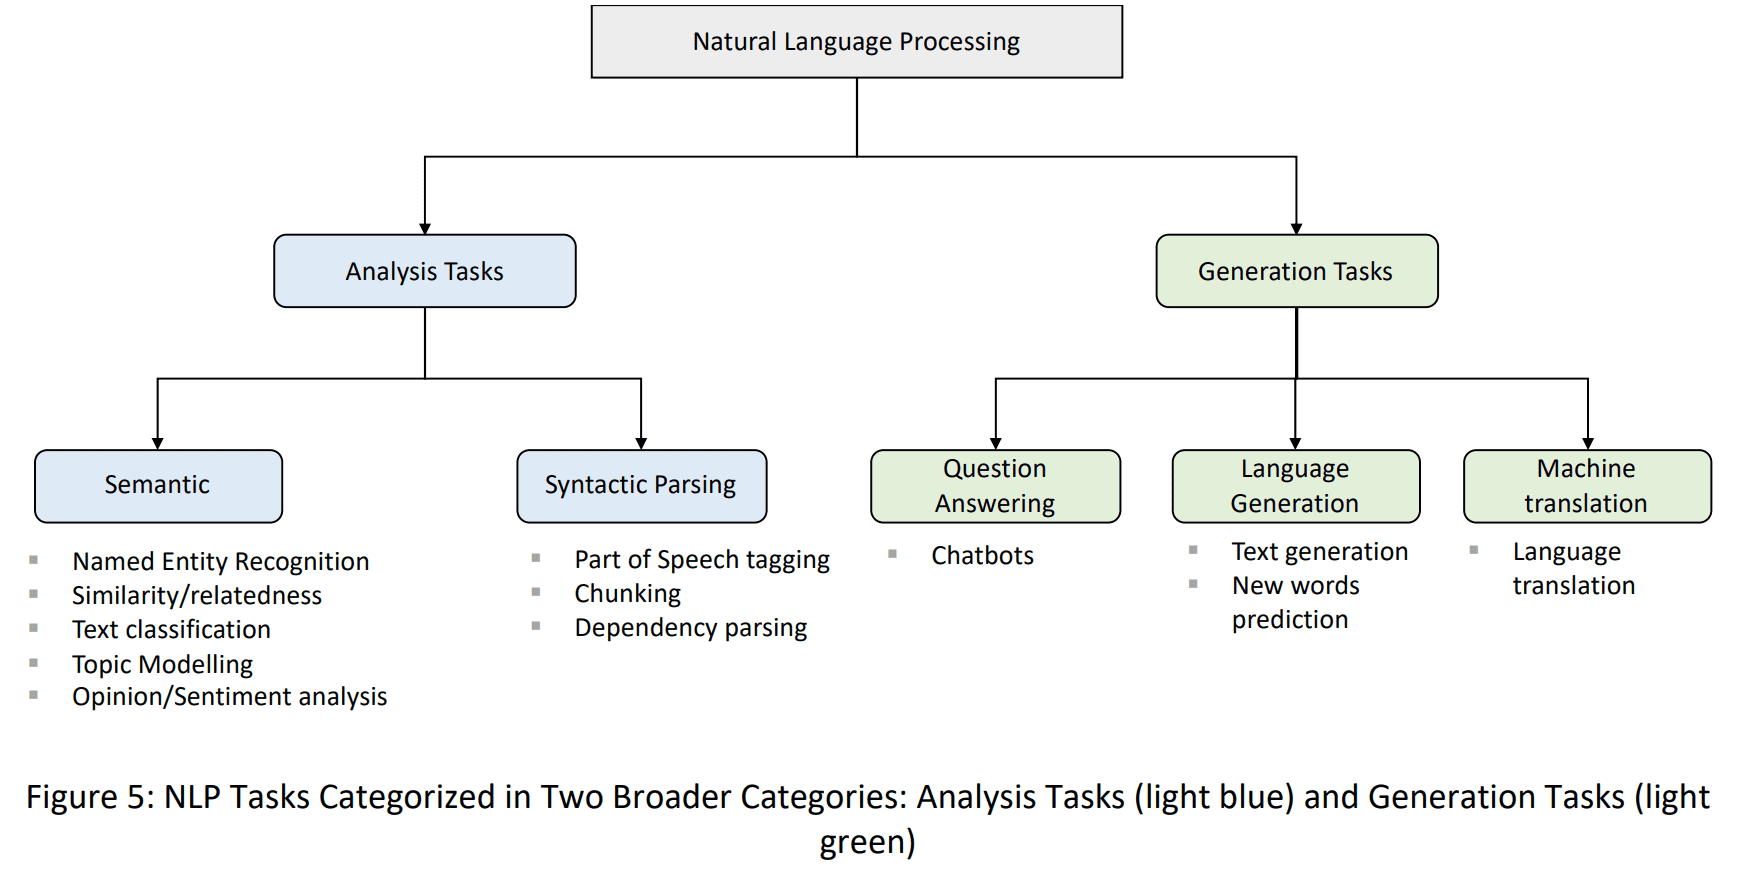

[Источник](https://www.researchgate.net/publication/343323519_Meshing_Capability_and_Threat-based_Science_and_Technology_ST_Resource_Allocation/figures?lo=1&utm_source=google&utm_medium=organic)

## Способы токенизации текста

В любой задаче машинного обучения мы строим некоторую модель, которая принимает на вход данные в числовом формате и возвращает числовой ответ. Обработка естественного языка не является исключением, поэтому нам очень важно решить задачу **перевода текста в числовое представление**.

Очевидно, что кодировать текст некоторым вектором целиком не является оптимальным решением &ndash; такой вектор будет содержать слишком мало информации, и, кроме того, различных текстов бесконечно много. Таким образом, прежде чем переводить текст в числовое представление, нам необходимо разбить его на смысловые единицы (токены), которые и будут обрабатываться нашей моделью. Существует несколько подходов к такому разбиению (которое, кстати, называется токенизацией).

### Character-level

В качестве токенов будем брать отдельные символы.

**Плюсы:**
+ Очень маленький размер словаря
+ Легко кодировать любые слова &ndash; нет проблемы с out of vocabulary

**Минусы:**
- Длинные последовательности. Почему это плохо, если мы фактически получаем больше фичей? В данном случае наши признаки несут в себе очень маленькие куски информации об исходном тексте, и модели будет тяжело ее извлечь, так как нужно выучить сложные зависимости между токенами. Плюс это накладывает вычислительные расходы из-за того, что мы увеличиваем размер входных данных 
- Теряется языковая структура

### Word-level

В качестве токенов будем брать слова целиком.

**Плюсы:**
+ Последовательности токенов после такого разбиения будут получаться достаточно короткими + более репрезентативные признаки
+ Сохраняется структура языка

**Минусы:**
- Большой размер словаря
- Нет токенов для новых слов, не входящих в наш словарь (частичное решение проблемы &ndash; завести специальный токен \<UNK\> для новых слов, но такой токен не будет нести никакой смысловой нагрузки)

### Byte-pair encoding (BPE)

В качестве компромисса между предыдущими методами используется следующий алгоритм:

**Основная идея:** Будем строить словарь иерархически.

1. В качестве исходного словаря используются символы $\leftarrow$ `character-level`;

2. Подсчитываются частоты встречаемости всех пар символов;

3. Находится самая частая пара;

4. Данная пара добавляется в наш словарь;

5. Если размер словаря стал больше, чем изначально заданный, то заканчиваем. Иначе идем в пункт 2.

По итогу получаем словарь, где мы учитываем популярные сочетания букв/слогов/слов, причем используются исходные данные и знания о них. Получается, что мы закладываем inductive bias на уровне обработки данных. Таким образом мы сглаживаем проблемы, присущие наивным подходам. Данный способ токенизации широко используется в современных языковых моделях.

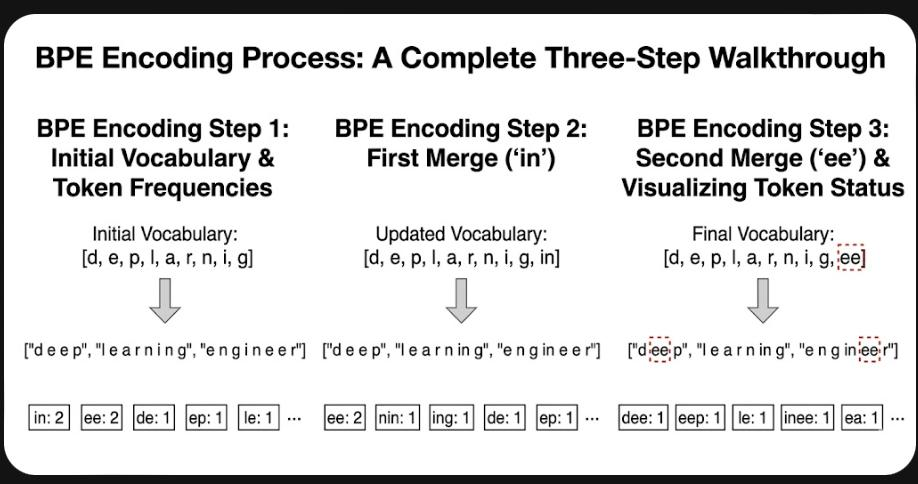

[Источник](https://youtu.be/hL4ZnAWSyuU?si=whhYeEEQ-u_92qmp)

### Это интересно

Построение словаря &ndash; важная и сложная задача. Например, для больших моделей есть эмпирические правила которые связывают число параметров, размер выборки и размер словаря, вы познакомитесь с ними на следующих занятиях.

Кроме того, иногда задача построения достаточно «хорошего» словаря может требовать особых знаний. Предположим, что ваша задача связана с органической химией. Для начала нужно понять, как превратить наши данные в числа. Например, молекулы и белки можно обрабатывать как графы, что требует сложных архитектур. 

С другой стороны, для каждого химического соединения существует представление в виде строки, которая называется [SMILES](https://ru.wikipedia.org/wiki/SMILES). Например, метил ($CH_3$) записывается как **CH3**, а этилен ($C_2H_4$) &ndash; **C=C** (так как присутствует двойная связь, а водород не пишется явно, если его можно вывести из валентности).

Соответственно, если перед вами стоит задача генерации химических соединений, то намного проще будет генерировать строки, а не графы &ndash; остается лишь выбрать подходящий словарь.

Самый простой вариант &ndash; работать на уровне символов. Тогда вы сможете получить совершенно любую строку, однако в процессе генерации могут возникнуть некорректные строки (не каждая строка соответствуют химическому соединению). Вы будете тратить мощность модель и время обучения на изучение структуры SMILES и корректных строк.

Продвинутый вариант &ndash; узнать, какую именно вы задачу решаете на практике. Например, если это синтез новых соединений, то часто вы знаете из каких «кусков» состоит результат. Например, соседний отдел коллег-химиков может подсказать вам, какие связи встречаются, встречаются ли у вас бензольные кольца и так далее. Благодаря этим знаниям вы можете составить словарь, из которого вы уже не сможете получить любое соединение, но любое сгенерированное соединение будет корректным.

Такая работа со словарем может превратить нерабочий метод в рабочий, так как закладывает знания в обработку данных и значительно упрощает решение задачи.

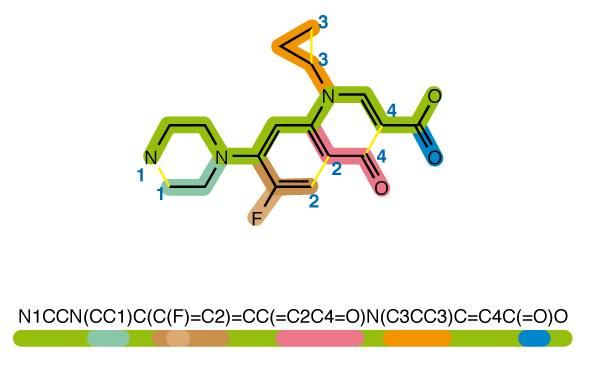

[Источник](https://ru.wikipedia.org/wiki/SMILES)

## Общая задача построения эмбеддингов

<font color='Red'> **Примечание:** </font> В русскоязычных текстах принято употреблять термин "векторное представление". Будьте внимательные в ваших курсовых, а также в любых других работах!


**Дано:** $D = \{w_1, w_2, . . . , w_{L_d}\}_{d=1}^{d=N}$ &ndash; корпус текста, $w_i \in W$ &ndash; словарь всевозможных слов (единиц конструкции предложения).

**Найти:** векторное представление $v_w \in R^m$ для каждого слова $w$, где $ m << |W|$

<font color='Orange'> **Вопрос:** </font> Что мы хотим получить от векторных представлений?

#### Ответ:


Далее мы будем считать, что хорошие представления будут иметь:

1. Соответствие близости по смыслу слов к близости по расстоянию между векторами.
2. Интерпретируемые арифметические операции над словами в пространстве эмбеддингов.
3. Хорошее качество при решении конечной задачи.

На самом деле, мы хотим не просто уменьшить вектора, но и иметь векторное пространство с операциями сохраняющим "смысл" слов.

Если мы сможем построить такие векторные представления, то **сразу решим задачи**:

1. Поиск близких слов, синонимов и т.п.
2. Получение представление документа, которое будет использоваться в других задачах машинного обучения.
3. Использование в качестве фиксированного представления в сложной архитектуре (например, рекуррентной сети*)
4. Использование для инициализации представлений в сложной архитектуре (снова рекуррентной сети*)

**Все эти аспекты рассмотрим на практике**

*Про рекуретные сети вы узнаете на следующей неделе

## Гипотиза дистрибутивности

Сделаем некоторые предположения, чтобы постараться хоть как-то подойти к нашей задаче построения хороших эмбеддингов. Благо, это уже было сделано за нас более полувека тому назад.

1. **Основная гипотеза, формулировка 1** ([Zellig S. Harris, 1954](https://www.tandfonline.com/doi/pdf/10.1080/00437956.1954.11659520), примерно 8400 цитирований):

    Слова, совстречающиеся с одними и теми же словами, имеют схожее значение.

2. **Основная гипотеза, формулировка 2** ([J. Firth, 1957](https://www.scirp.org/reference/ReferencesPapers?ReferenceID=1846447), примерно 5700 цитирований):

    Слово характеризуется словами, с которыми оно совстречается.

<font color='Orange'> **Вопрос:** </font> Как вы считаете, близка ли к реальности эта гипотеза? Какие примеры вы знаете, которые противоречат гипотезе?

#### Ответ:

В целом, гипотеза близка к реальности, однако есть исключения:
* В одном контексте часто могут встречаться слова с диаметрально противоположным значением
* В одном контексте могут встречаться различные имена собственные
* Слова, имеющие несколько различных значений, довольно тяжело характеризовать соседними словами
* В некоторых языках отрицательная частица ставится в конец предложения, хоть она и связана с глаголом в начале (например, частица nicht в немецком)

## Основные подходы к построению эмбеддингов

### Подход #0: BOW и Tf-Idf

В базовом курсе машинного обучения вы познакомились с базовыми методами кодирования слов &ndash; **BoW** и **Tf-Idf**. Они опираются на частоту встречаемости слов в корпусе (**count-based** методы).

<div>
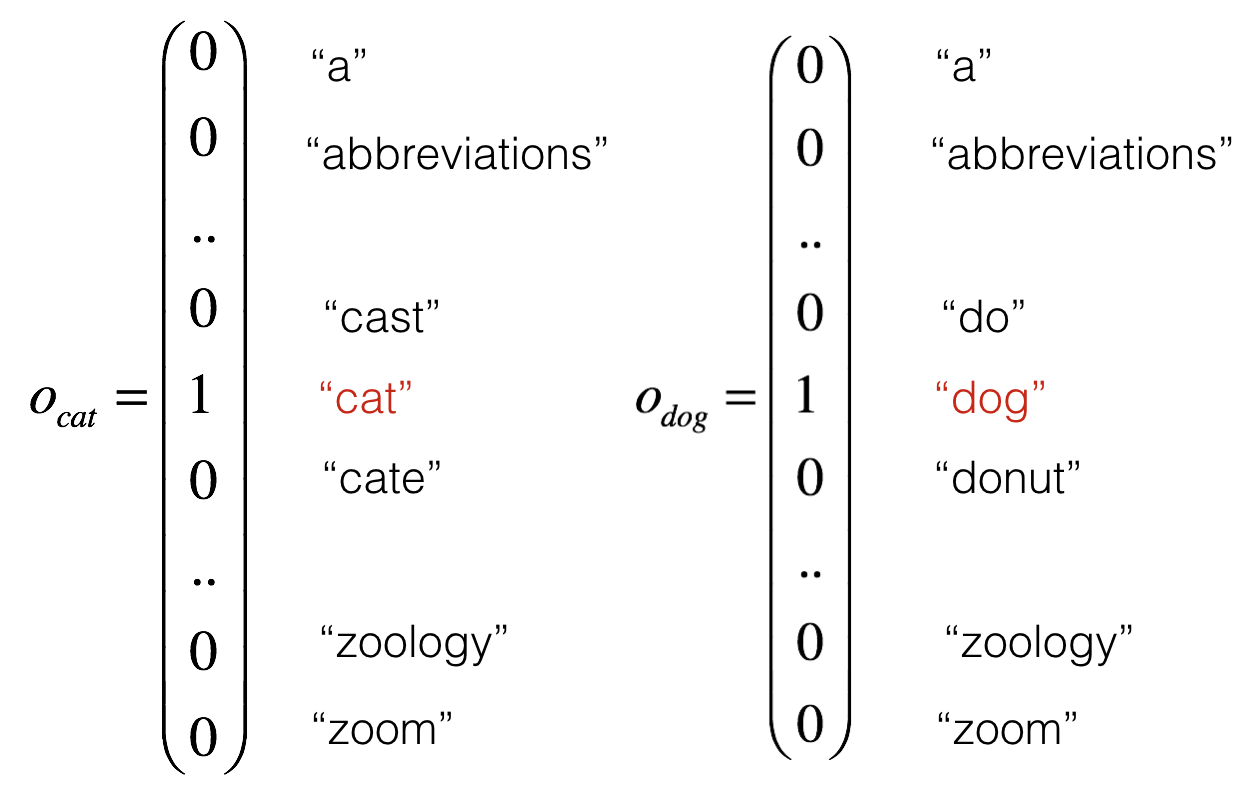
</div>

<font color='Orange'> **Вопрос:** </font> Какие проблемы имеются у данных подходов?

#### Ответ:

Основные проблемы:
* Получившиеся векторные представления имеют размерность, равную размеру словаря, что очень много
* В векторы никак не зашита информация о порядке слов в тексте, об их семантике и контексте

### Подход #1: Более умные Count-based методы

Наша цель сохранить в векторах смыслы слов и контекста, а также уменьшить размерность. Если слова зависят друг от соседних слов (в каком-то контексте), тогда попробуем зашить эту информацию в итоговые векторы.

Для начала формально определим, что значит "слово $c$ является контекстом слова $w$". Под контекстом слова $w$ будем понимать $k$ слов слева и $k$ слов справа от $w$, обозначим его $C(w)$. Таким образом, фраза выше означает то, что $c \in C(w)$. Обозначим за $n_{w, c}$ количество раз, когда слово $c$ являлось контекстом слова $w$ и определим следующие величины ([Peter D. Turney and Patrick Pantel, 2010](https://arxiv.org/abs/1003.1141)):
\begin{align*}
    &p(w, c) = \frac{n_{w, c}}{\sum_{i = 1}^N \sum_{j = 1}^N {n_{i, j}}} \\
    &p(w{*}) = \frac{\sum_{c = 1}^N n_{w, c}}{\sum_{i = 1}^N \sum_{j = 1}^N {n_{i, j}}} \\
    &p({*}c) = \frac{\sum_{w = 1}^N n_{w, c}}{\sum_{i = 1}^N \sum_{j = 1}^N {n_{i, j}}}
\end{align*}

Здесь:
* $p(w, c)$ &ndash; вероятность встретить слово $c$ в контексте слова $w$
* $p(w{*})$ &ndash; вероятность встретить слово $w$ в качестве слова, контекст которого мы рассматриваем
* $p({*}c)$ &ndash; вероятность встретить слово $c$ в произвольном контексте

Запишем, чему равна взаимная информация двух слов (pointwise mutual information/PMI), что по смыслу отвечает на вопрос: "Насколько одно слово влияет на другое?".

\begin{align*}
    PMI(w, с) = \log \frac{p(w, с)}{p(w{*})p({*}c)}
\end{align*}

Если раскрыть счетчики в формулах вероятностей, то получим:
\begin{align*}
    PMI(w, с) = \log \frac{n_{w, с} \cdot N}{n_{w{*}} n_{{*}c}}
\end{align*}
Здесь $N$ &ndash; количество рассмотренных пар $(w, c)$.

Рассмотрим позитивную взаимную информацию (Positive	PMI/PPMI):

\begin{align*}
    PPMI(w, c) = \max(0, PMI(w, c))
\end{align*}

Составим матрицу $X \in \mathbb{R}^{|W| \times |W|}$, где $X_{w, c} = PPMI(w, c)$.

<font color='Orange'> **Вопрос:** </font> Какая матрица это будет? Как это соотносится с реальным языком?

#### Ответ:

Получим сильно разреженную матрицу, содержащую информацию о взаимной совстречаемости слов, так как $X_{i, j} > 0$, если слова i, j встречаются в одном контексте чаще, чем по отдельности.

*Взаимная информация прошла из теории информация, любопытные могут прочитать об этом подробнее в соотвествующих книгах :)

#### Итог

Мы получили очень большую разреженную матрицу, в которой содержится полезная информация, теперь давайте уменьшим ее размер. Для этого воспользуемся методами понижения размерности, например, SVD разложением.

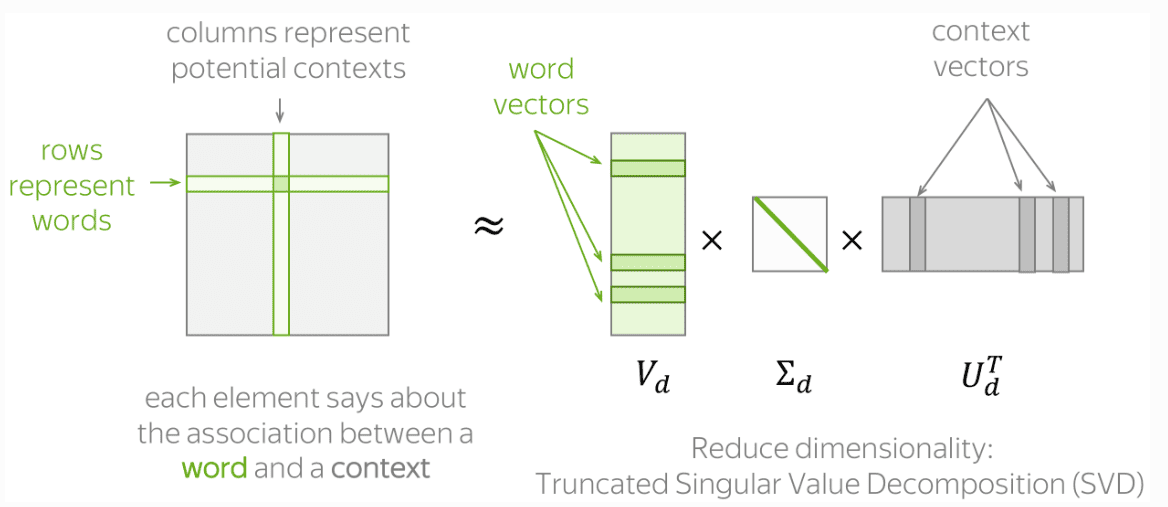

[Источник](https://lena-voita.github.io/nlp_course/word_embeddings.html)

Когда мы получили матрицу взаимодействий мы уже решили прикладную задачу. Задача уменьшения размерности матрицы с сохранением "информации" является задачей методов оптимизации (alternating least squares, ...) или линейной алгебры (SVD, TT-SVD, ...). Посмотрим на подход, в котором мы строим наши матрицы путем оптимизации некоторого функционала.

### Glove: Global Vectors for Word Representation

[Jeffrey Pennington et al., 2014](https://nlp.stanford.edu/pubs/glove.pdf), примерно 50 тысяч цитирований

Зададим матрицы $U$ и $V$, которые будут содержать вектора слов и контекста соответственно. 

Обозначим $P_{w, c} := P(c \mid w)$ и будем учить $U, V$ так, чтобы 
$$
    u^T_w v_c \approx \log P_{w, c} = \log \frac{n_{w, c}}{n_{w*}}
$$
Это будет означать, что векторы, соответствующие семантически схожим словам, будут близки с точки зрения скалярного произведения.
Для этого будем решать следующую оптимизационную задачу:
    
\begin{align}
&\mathcal{L} = \sum_{w \in W} \sum_{c \in W} F(n_{w, c}) \biggl(u_w^Tv_c + b_w + \hat{b}_c - \log n_{w, c} \biggr)^2 \to \min_{U, V, b_w, \hat{b_c}}\\
&F(n) = \begin{cases}
\frac{n_{w,c}}{n_{max}}^{\alpha}, \quad \text{if } n_{w,c} < n_{max}\\
1, \quad \text{иначе}
\end{cases}\\
&\alpha = \frac{3}{4}, n_{max} = 100, \quad \text{гиперпараметры из статьи}.
\end{align}

* Чем чаще вместе встречаются слова $w$ и $c$, тем больший вклад в функционал вносит соответствующее им слагаемое $\Rightarrow$ тем важнее достичь близости $u_w^Tv_c + b_w + \hat{b}_v$ и $\log n_{w, c}$.
* Слагаемые $b_w, \hat{b}_c$ возникают в силу того, что $\log P_{w, c} = \log n_{w, c} - \underbrace{\log{n_{w*}}}_{\text{не зависит от c}}$ ($b_w$ для симметрии). *Да, мы могли бы собрать статистику* $n_{w*}$ *по корпусу так же, как мы собираем $n_{w,c}$, и не учить смещения, но тогда пропала бы симметрия при замене слова и контекста, а авторы статьи хотят ее сохранить для того, чтобы в качестве финального эмбеддинга брать сумму строк обеих матриц*. Можно ввести следующую интуицию: $u_w, v_c$ отвечают за смысловую связь, $b_w, \hat{b}_c$ &ndash; за частоту встречаемости слов в корпусе.


**Алгоритм обучения:**
* Проходимся по корпусу и строим матрицу $X_{ij} = n_{i, j}$
* Инициализируем $U, V$
* Минимизируем функцию потерь градиентными методами
* В качестве финального эмбеддинга можно брать $u_w + v_w$

Подробнее можно почитать в статье, интуиция и вывод функционала очень интересен и любопытен, **хороший пример** как люди старались заложить ожидания от решения в задачу оптимизации.

На практике Glove используется, но **работает хуже** более продвинутых методов, которые мы рассмотрим ниже.

### Общее замечания к методам, основанным на подсчете

**Преимущества**:

- Неплохое качество в некоторых задачах (но нужно уметь настраивать)
- Маленькая размерность
- Близким словам соответствуют близкие вектора

**Недостатки**

- Нет хорошего механизма обработки новых слов на тесте
- **Основной минус**: необходимо собирать огромную (но разреженную!) матрицу совстречаемостей для обучения

Так как нет возможности добавлять новые слова и необходимость хранения матрицы, этот подход **не** подходит для нейронных сетей и больших датасетов. Нам нужны **масштабируемые** методы.

### Подход #2: Prediction-based (word2vec)

[Tomas Mikolov et al., 2013](https://arxiv.org/abs/1301.3781), примерно 52 тысячи цитирований

Строить эмбединги хоть как-нибудь хорошо мы научились выше. Теперь наша цель обновлять их "на ходу", чтобы адаптировать под новые данные и учить **масштабируемые модели**.


**Идея:**

Будем обучать модель «воспроизводить» локально гипотезу Фёрса (версия 2). Есть **два** основных подхода:


- Модель CBOW &ndash; по словам контекста необходимо предсказать центральное слово
- Модель Skip-gram &ndash; по центральному слову, необходимо предсказать каждое из слов контекста



**Модель CBOW (continuous bag of words)**

Если слово характеризуется соседними словами, значит мы можем можем **предсказать слово** по **контексту**.

**Модель Skip-gram**

Если слово характеризуется соседними словами, значит мы можем можем **предсказать контекст** по **слову**.

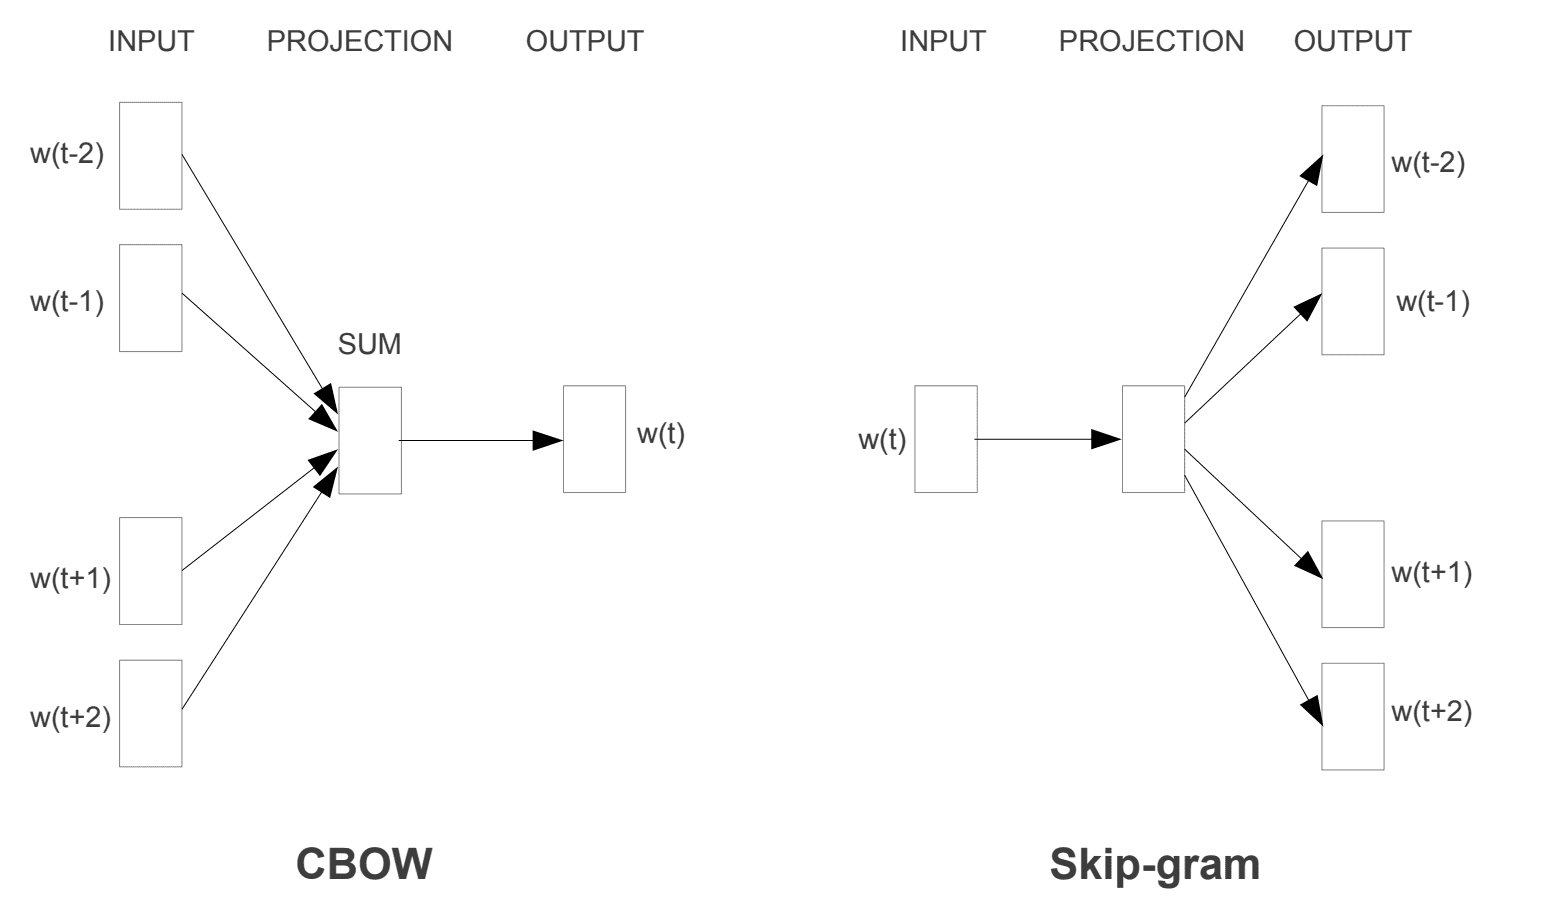

[Источник](https://arxiv.org/abs/1301.3781)

Далее будем считать, что есть словарь $V$, матрица входных эмбеддингов $W \in \mathbb{R}^{|V| \times d}$, матрица выходных эмбеддингов $\hat{W} \in \mathbb{R}^{|V| \times d}$. Каждое слово имеет входной вектор $w_i$ и выходной вектор $\hat{w}_i$.


Почему две матрицы:
- Не накладываем дополнительного ограничения (симметричность) на входные данные
- Проще считать градиенты &ndash; быстрее обучаемся

**Функционал CBOW**

Будем считать, что $C(v_i)$ контекст слова $v_i$, например $k$ слов слева и справа.
\begin{align*}
&\sum_{i}^N \log p(v_i | C(v_i)) \to \max_{W, \hat{W}}\\
&p(v_i | C(v_i)) = softmax(h\hat{W}^{T})_{v_i}\\
&h = \frac{1}{|C(v_i)|} \sum_{v \in C(v_i)} W_v
\end{align*}

**Функционал Skip-Gram**


\begin{align*}
&\sum_{i}^N  \sum_{v \in C(v_i)} \log p(v | v_i) \to \max_{W, W'}\\
&p(v | v_i) = softmax(W_{v} \hat{W}^{T})_{v_i}\\
\end{align*}


В качестве эмбеддингов выбираются $w_i$ или $w_i + \hat{w}_i$.

**Замечание**

- На практике skip-gram намного лучше моделируют редкие слова

- Skip-gram на практике намного медленее CBOW

- Есть методы ускорения обучания: Negative sampling, Hierarchical softmax из работы [Tomas Mikolov et al., 2013](https://arxiv.org/abs/1310.4546), примерно 50 тысяч цитирований


<div>
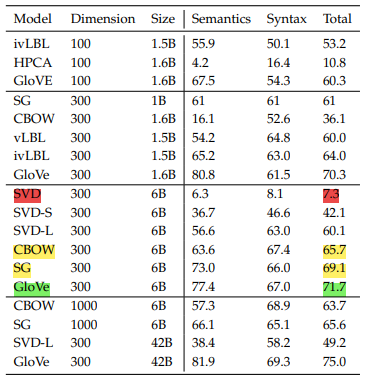
</div>

[Источник таблички](https://web.stanford.edu/class/archive/cs/cs224n/cs224n.1224/readings/cs224n-2019-notes02-wordvecs2.pdf)

### Общие замечания к методам основанным на предсказании

**Преимущества**:

- Маленькая размерность
- Близким словам соответствуют близкие вектора
- Обучаются градиентно по датасету

**Недостатки**

- Плохой механизм обработки новых слов на тесте
- Требуют большего корпуса чем count-based модели

Так как нет возможности добавлять новые слова и необходимость хранения матрицы, этот подход **не** подходит для нейронных сетей и больших датасетов. Нам нужны **масштабируемые** методы.

Удачное расширение skip-gram &ndash; модель **FastText** ([Piotr Bojanowski et al., 2017](https://arxiv.org/abs/1607.04606), примерно 15 тысяч цитирований). Для этого предположим, что эмбеддинг слова представляются суммой эмбеддингов его буквенных n-грамм, и будем учить именно их. Это удачно работает с **лингвистической точки зрения**: смысл слова определяется приставкой, корнем, суффиксом и окончанием. Кроме того, мы теперь можем  обрабатывать Out-Of-Vocabulary слова, так как каждое слово состоит из набора слогов.

## Способы работы с эмбеддингами

Итак, мы научились строить эмбеддинги, которые соответствуют нашим предположениям об их свойствах. Давайте теперь посмотрим, как мы можем работать с полученными векторными представлениями.

### Измерение близости слов

Для измерения сходства двух слов можно использовать предположение о близости по некоторой метрике их эмбеддингов.

Рассмотрим косинусную меру сходства:

$$\mathrm{CosineSimilarity}(u, v) = \frac{u \cdot v} {||u||_2 ||v||_2} = \cos(\theta),$$
$\theta$ &ndash; угол между векторами $u$ и $v$.

<div>
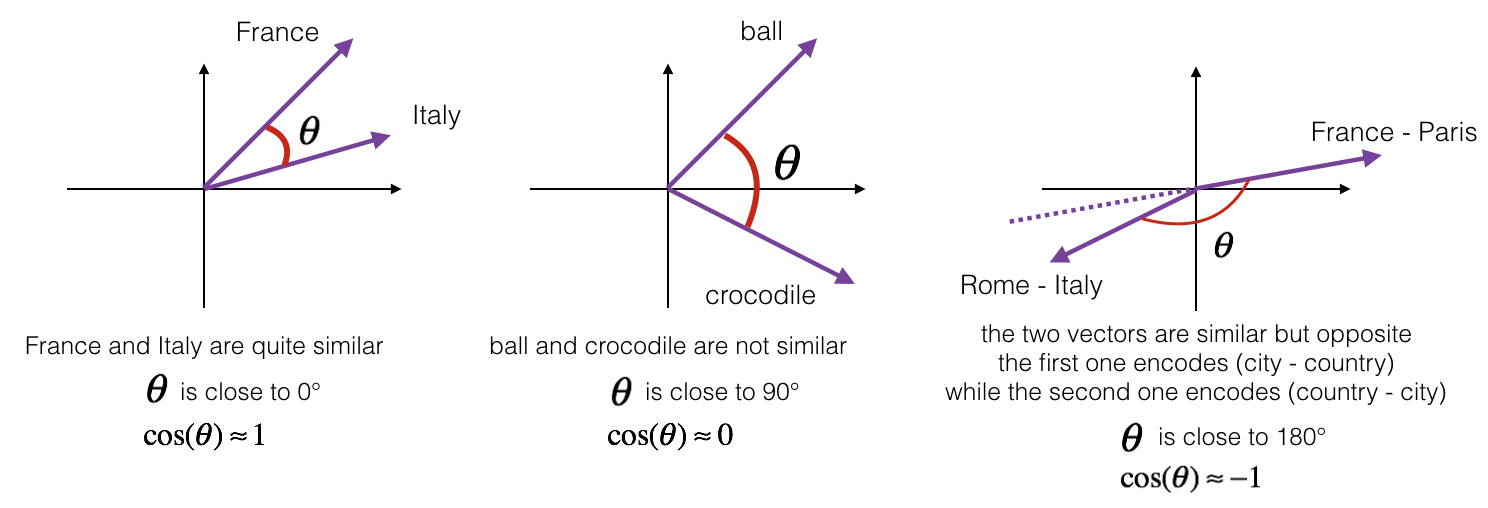
</div>

[Источник](https://www.researchgate.net/publication/355339249_Automatic_text_summarization_using_a_filter-based_approach)

### Арифметика в поле эмбеддингов

Основное свойство, которое мы хотим получить от эмбеддингов -- это соответствие математичеких операций над векторами слов аналогичным им смысловым операциям над самими словами. Давайте рассмотрим изображения

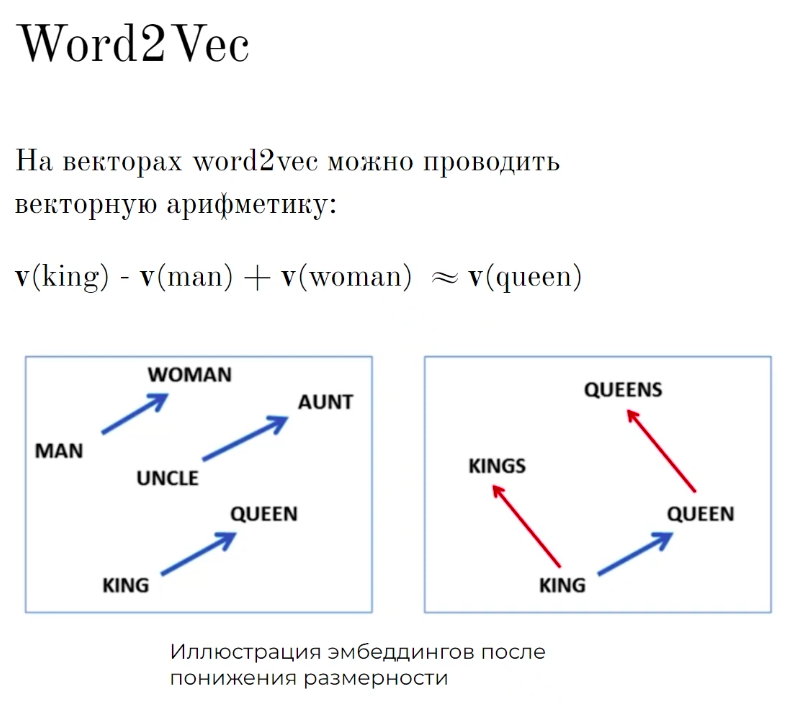

[Источник](https://youtu.be/WbtQzAvhnRI?si=4oEwSsDXPs_CPQsd&t=1336)

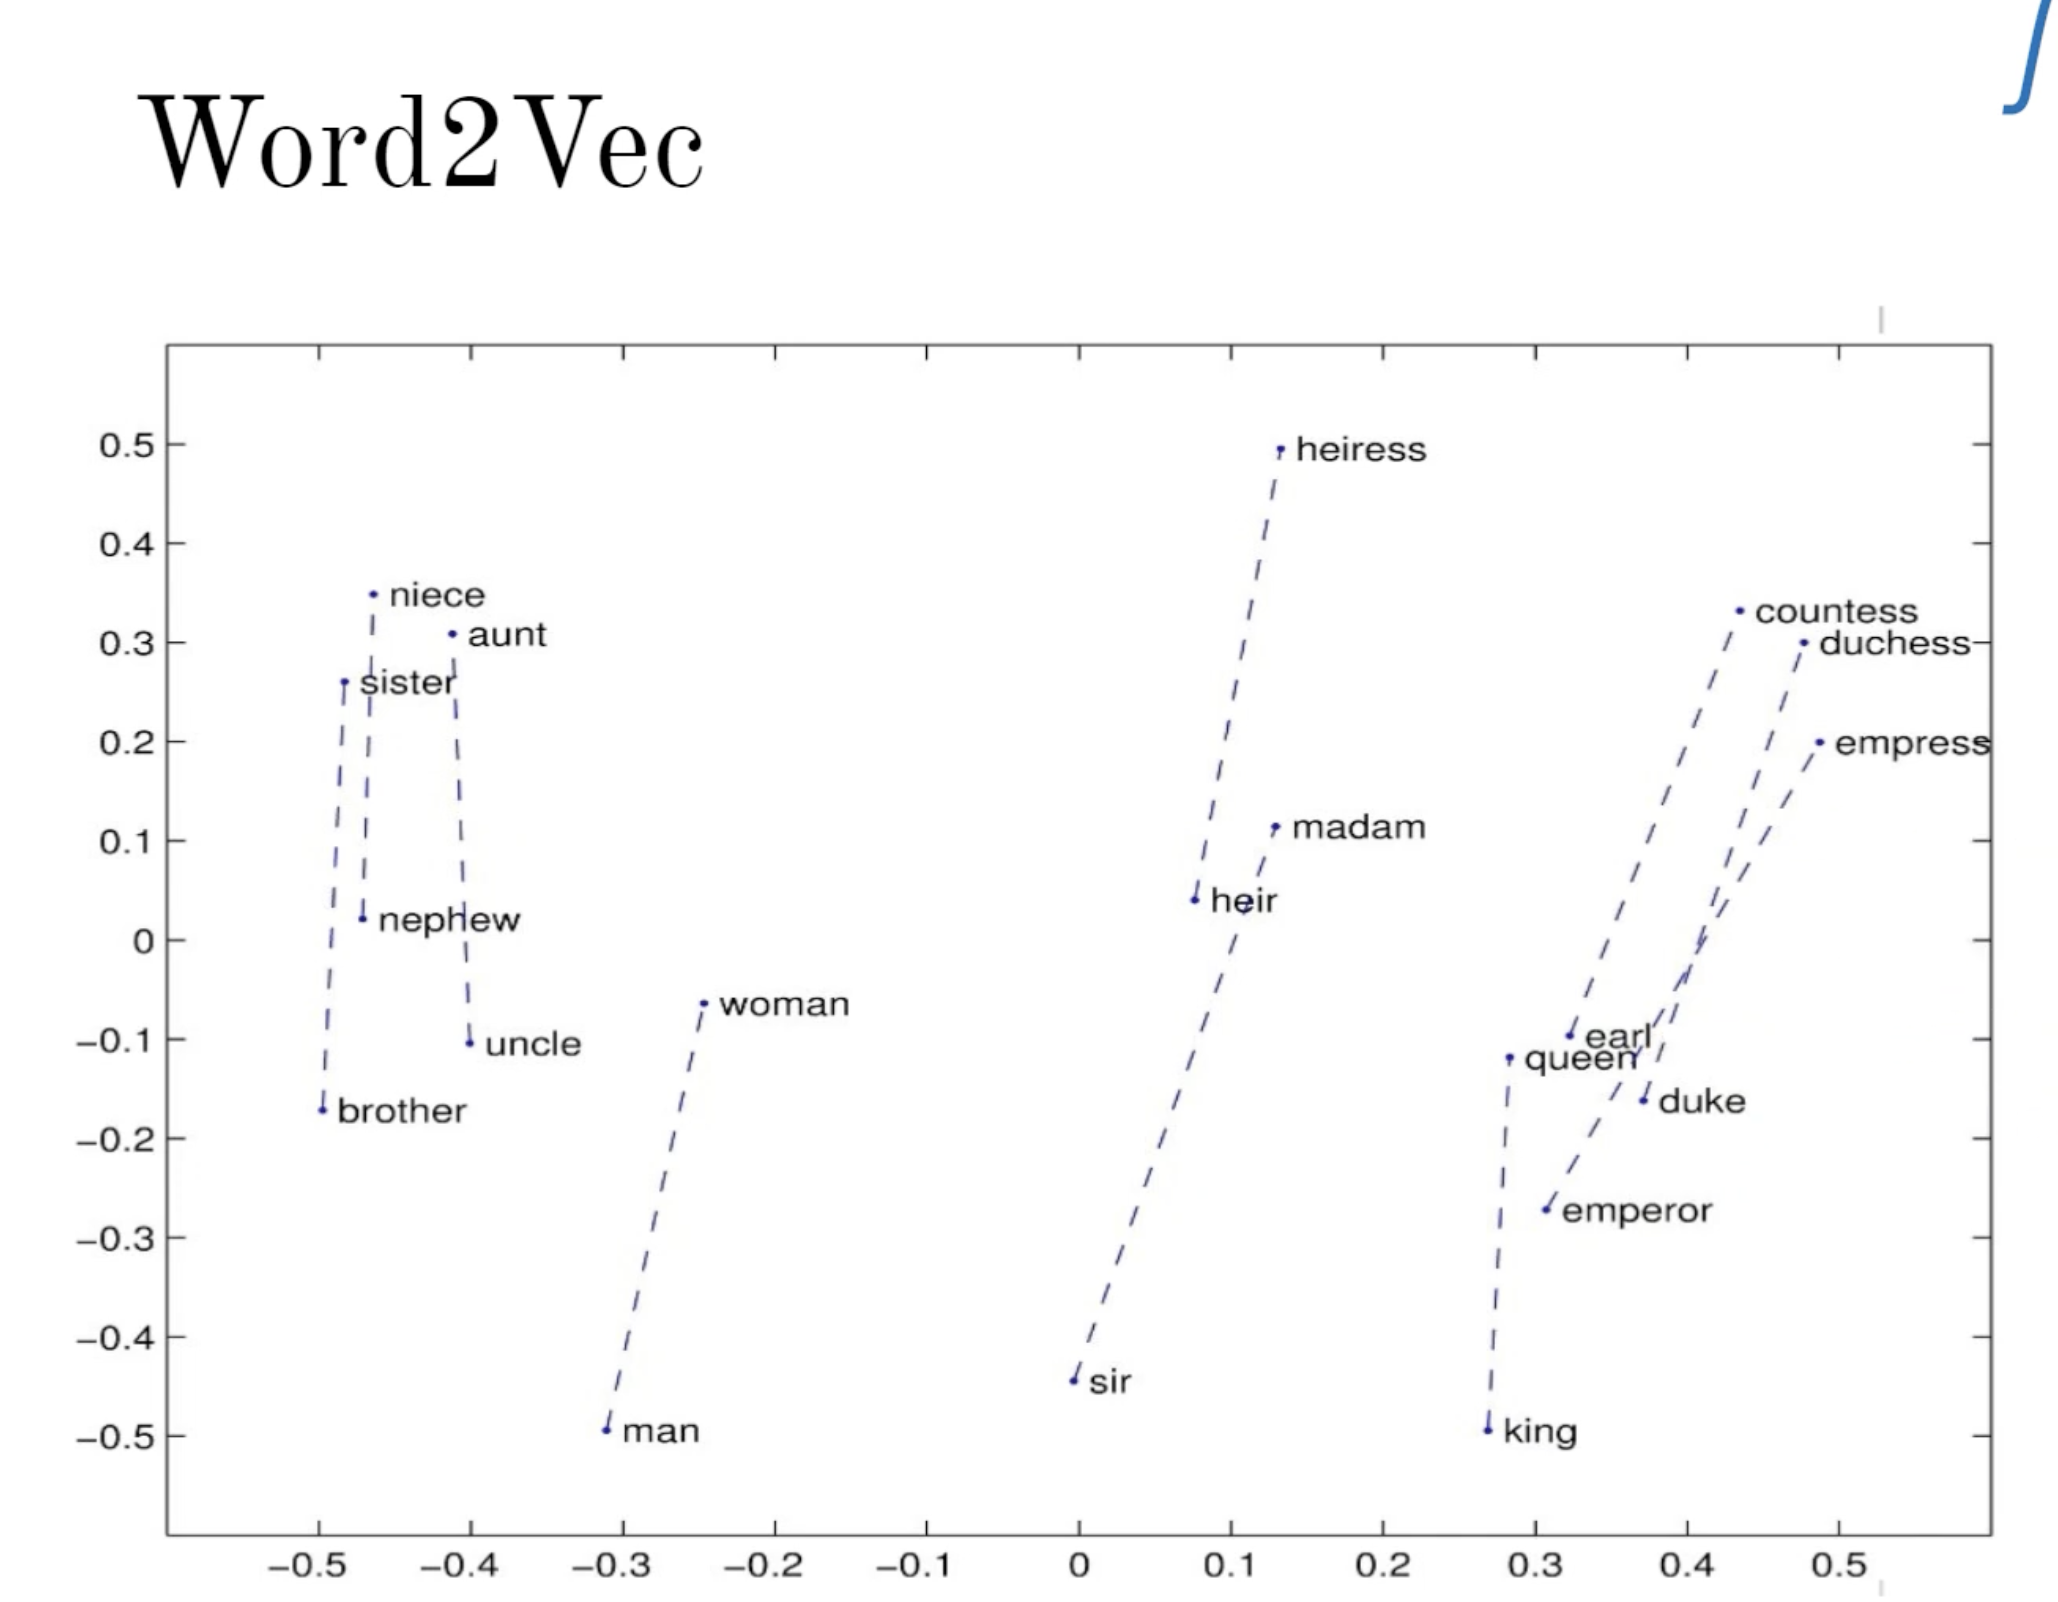

[Источник](https://www.youtube.com/watch?v=WbtQzAvhnRI&t=1536s)

## Сравнение методов

Мы сегодня рассмотрели достаточно простые методы создания эмбеддингов, но достаточно эффективные, если посмотреть на изображение ниже, то можно увидеть незначительное отставание GloVe даже от XXL моделей. В общем данные подходы являются очень сильными бейзлайнами.

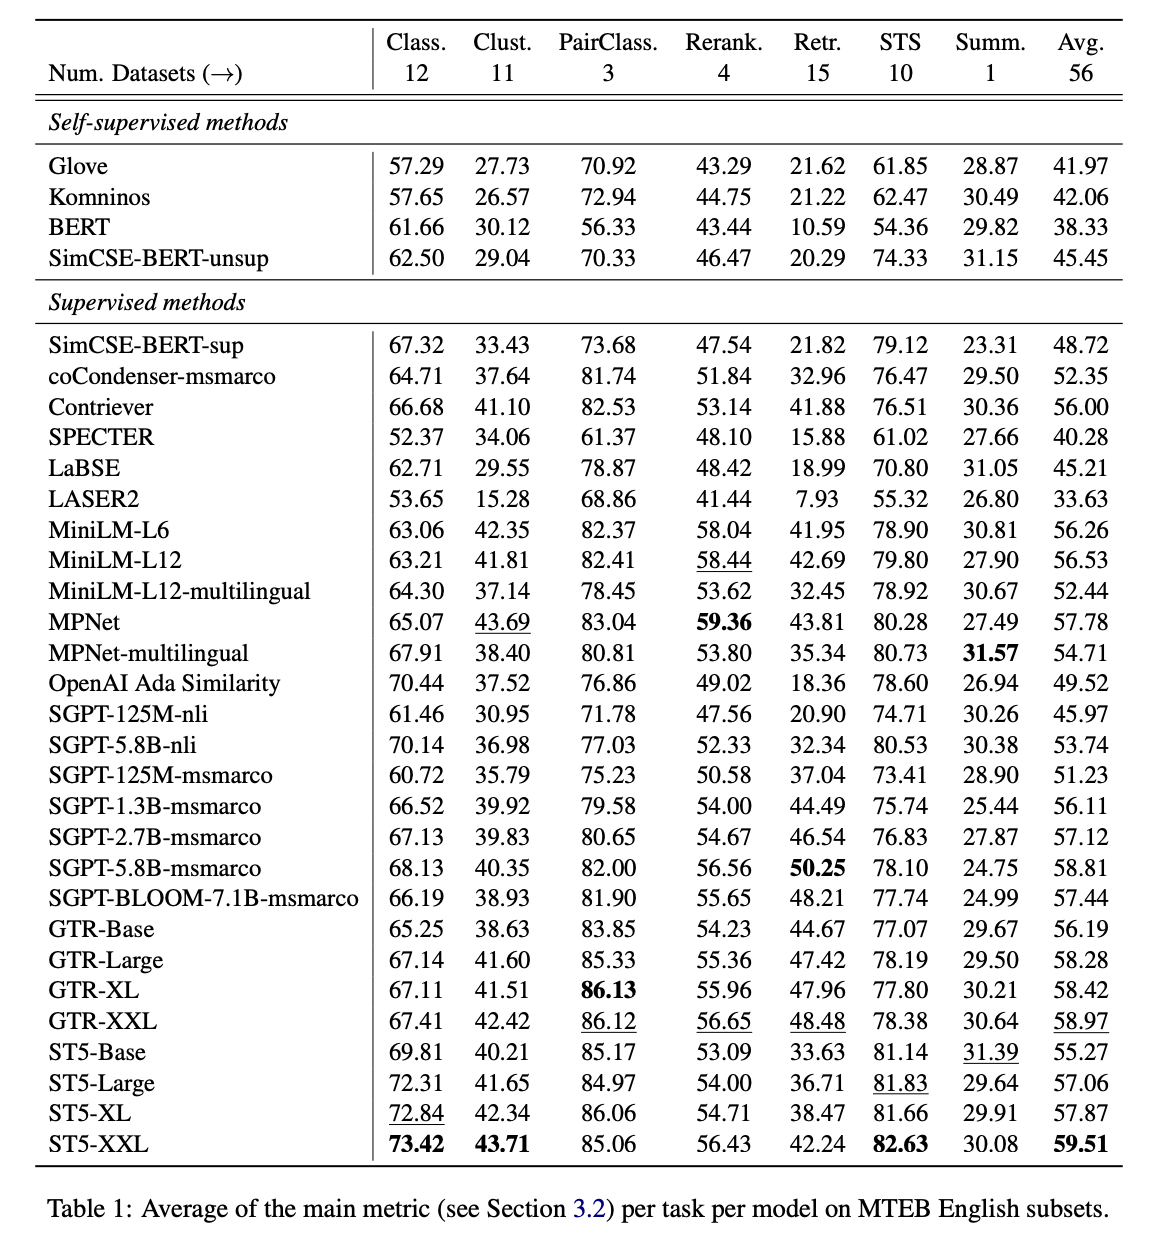

[Источник](https://arxiv.org/pdf/2210.07316)

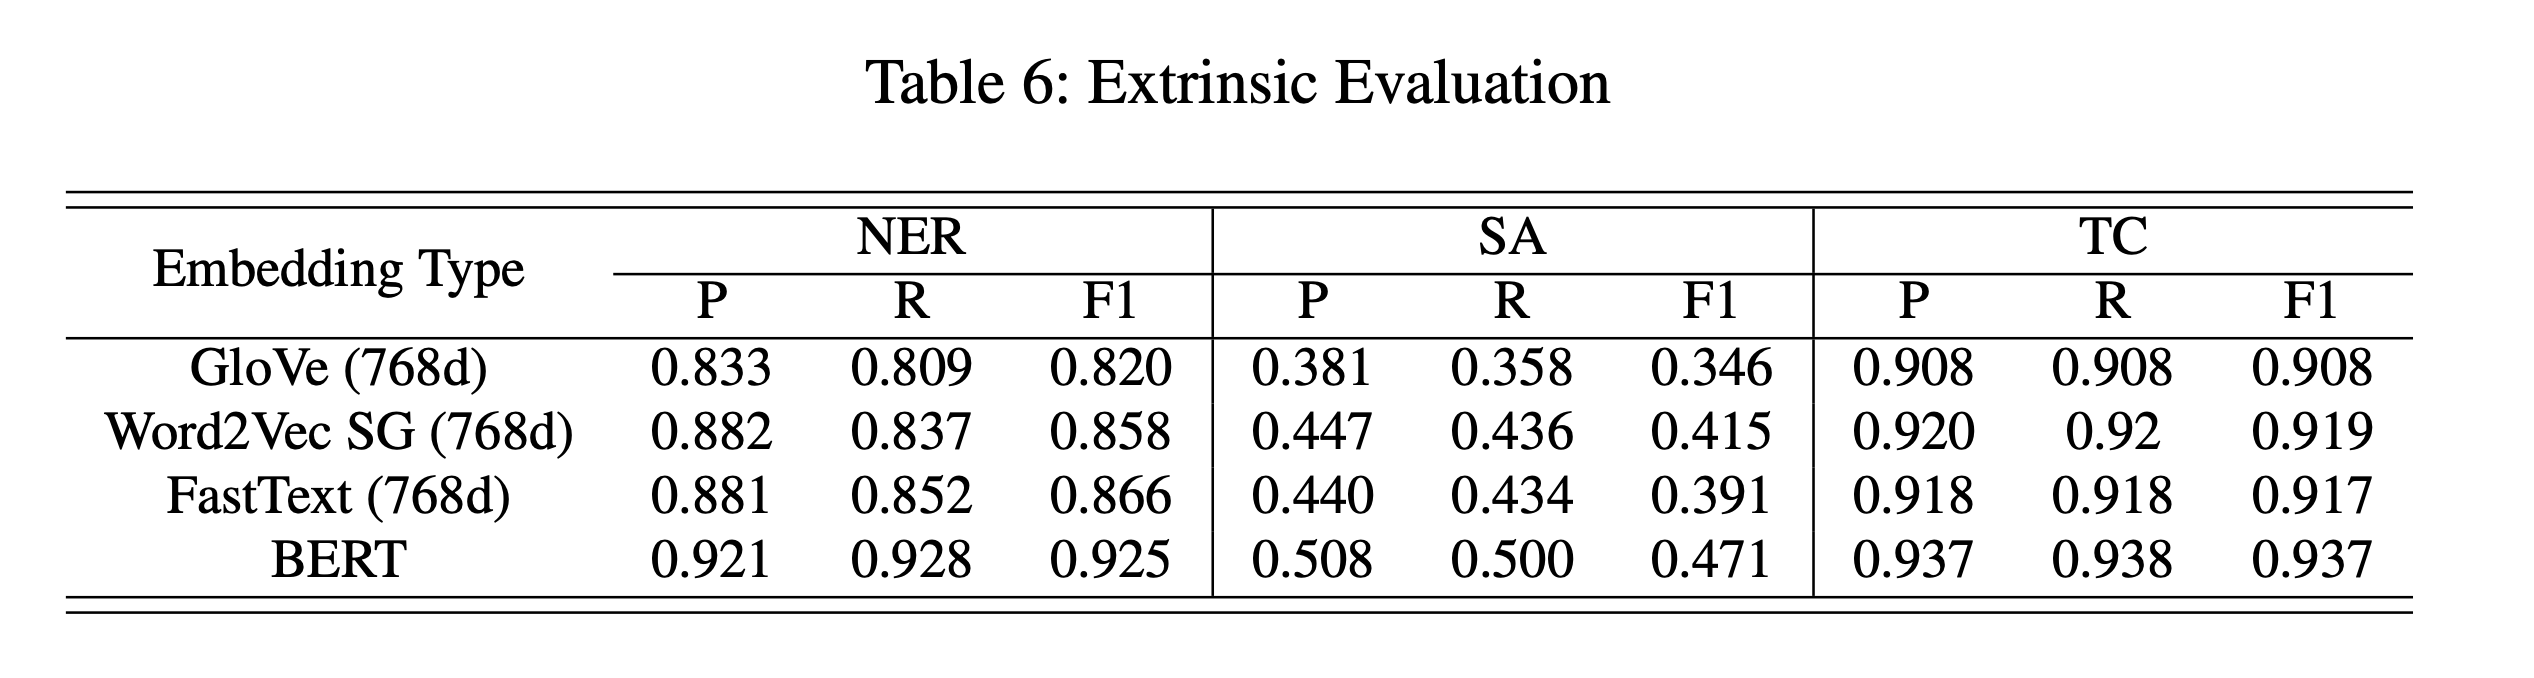

[Источник](https://hal.science/hal-03148517/document)

## Применение в реальных задачах

В современном мире все трубят о больших языковых моделях, поэтому будем рассматривать именно задачу генерации текста. Формально мы можем записать это следующим образом:

**Дано:** Выборка документов $\mathcal{D} = \{ d_1,\dots, d_N \}$. Каждый документ содержит слова $w_1, \dots, w_{L_{d}}$, где  $L_{d}$ число слов в документе $d$.

**Найти:** Для любого множества слов $(w_1, \ldots , w_k)$ оценить вероятность следующего слова в предложении, то есть найти условное распределение:

\begin{gather*}
p(w|w_1, . . . , w_k)
\end{gather*}

Нетрудно понять, что при инференсе нашей модели наличие в эмбеддингах информации о семантике слов критически важно. Без него модель может не учесть важные связи между словами в последовательности и, как следствие, выдать неправильное распределение, сломав генерацию.

## Эмбеддинги в PyTorch

Самый простой  и лучший (в смысле некоторой обучаемой модели, а не семантической интерпретируемости) способ обучить эмбеддинги &ndash; инициализировать векторы случайным образом, а затем пропускать по ним градиент, т.е. рассматривать как обучаемый параметр при прямом проходе сети. Таким образом мы можем выучить наши эмбеддинги под конкретную задачу. Также отлично работает инициализация известными эмбеддингами, теми же Glove и FastText.

```python
torch.nn.Embedding(
    num_embeddings: int,
    embedding_dim: int,
    padding_idx: Optional[int] = None,
    max_norm: Optional[float] = None,
    norm_type: float = 2.0,
    scale_grad_by_freq: bool = False,
    sparse: bool = False,
    _weight: Optional[torch.Tensor] = None,
    _freeze: bool = False,
    device=None,
    dtype=None,
) -> None
```

**Инициализация Эмбеддингов: класс `torch.nn.Embedding`**

* `num_embeddings` (int) &ndash; размер словаря (количество слов, требующих эмбеддингов). Включает в себя спец. слова. Можно передавать `vocab.__len__`

* `embedding_dim` (int) &ndash размерность изучаемого представления.

* `padding_idx` (int, optional) &ndash если указан, то вектор соответствующий этому токену обучаться не будет, по умолчанию будет равен 0.

**Важно!** padding_idx используется для обособления начала/конца строки. Векторы других спец символов, например `<unk>`, обучаться будут.

* `max_norm` (float, optional) &ndash максимальная норма векторного представления, если таковая указана.

* `norm_type` (float, optional) &ndash параметр нормы (p-norm).

* `scale_grad_by_freq` (bool, optional) &ndash Если True, то градиенты будут считаться с учётом частоты слова в мини-батче.

* `sparse` (bool, optional) &ndash Если `True`, то градиент по матрице эмбеддингов будет вычисляться в sparse виде. (Нужно, например, если вы захотели дообучить некоторые из приведённых ранее эмбеддингов)
